<a href="https://colab.research.google.com/github/huyhoangg/ComputerVision_HCMUT/blob/main/ImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ic_path = "/content/drive/MyDrive/DeepLearning/Assignment1/ImageClassification"
os.makedirs(ic_path, exist_ok=True)

In [ ]:
batch_size = 64

Load dataset và thực hiện EDA

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

IMAGENET_train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

IMAGENET_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

train_dataset_full = torchvision.datasets.CIFAR10(
    root="/content/data",
    train=True,
    download=True,
    transform=IMAGENET_train_transform
)

val_dataset_full = torchvision.datasets.CIFAR10(
    root="/content/data",
    train=True,
    download=False,
    transform=IMAGENET_test_transform
)

train_size = int(0.9 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

generator = torch.Generator().manual_seed(42)

indices = torch.randperm(len(train_dataset_full), generator=generator)

train_indices = indices[:train_size]
val_indices = indices[train_size:]

trainset = Subset(train_dataset_full, train_indices)
valset = Subset(val_dataset_full, val_indices)

trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
valloader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)

# test dataset
testset = torchvision.datasets.CIFAR10(
    root="/content/data",
    train=False,
    download=True,
    transform=IMAGENET_test_transform
)

testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

classes = (
    "airplane","automobile","bird","cat",
    "deer","dog","frog","horse","ship","truck"
)

100%|██████████| 170M/170M [00:03<00:00, 42.9MB/s]


Kiểm tra dữ liệu toàn vẹn : không bị thiếu

In [ ]:
import torch

def check_missing(dataset):
    missing_count = 0
    for i in range(len(dataset)):
        img, label = dataset[i]
        if img is None or label is None:
            missing_count += 1
    print(f"Missing samples: {missing_count}/{len(dataset)}")

check_missing(train_dataset_full)
check_missing(testset)

Missing samples: 0/50000
Missing samples: 0/10000


Kết quả dữ liệu cân bằng : cân bằng

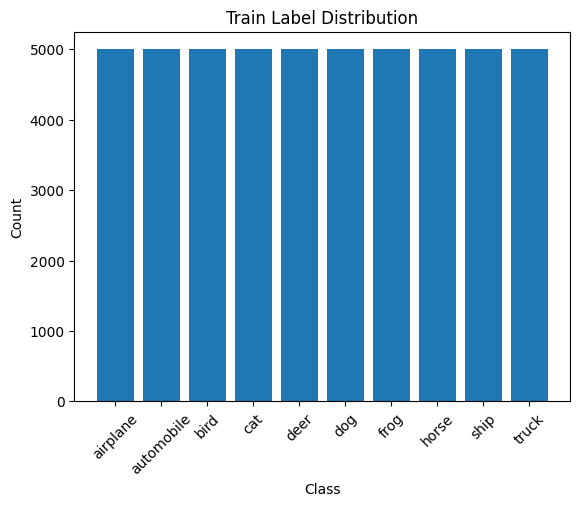

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

def plot_label_distribution(dataset, title):
    labels = [dataset[i][1] for i in range(len(dataset))]
    counter = Counter(labels)

    classes = [
        "airplane","automobile","bird","cat",
        "deer","dog","frog","horse","ship","truck"
    ]

    counts = [counter[i] for i in range(len(classes))]

    plt.figure()
    plt.bar(classes, counts)
    plt.xticks(rotation=45)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

plot_label_distribution(train_dataset_full, "Train Label Distribution")

Kiểm tra một số mẫu của dữ liệu

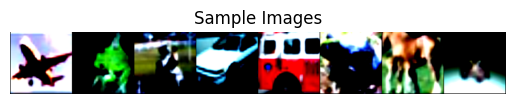

In [ ]:

def show_samples(loader):
    dataiter = iter(loader)
    images, labels = next(dataiter)

    grid = torchvision.utils.make_grid(images[:8])

    plt.figure()
    plt.imshow(grid.permute(1,2,0))
    plt.title("Sample Images")
    plt.axis("off")
    plt.show()

show_samples(trainloader)

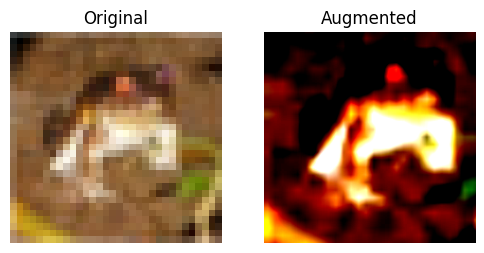

In [ ]:

raw_dataset = torchvision.datasets.CIFAR10(
    root="/content/data",
    train=True,
    download=False,
    transform=transforms.ToTensor()
)

def compare_augmentation(idx=0):
    raw_img, _ = raw_dataset[idx]
    aug_img, _ = train_dataset_full[idx]

    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.imshow(raw_img.permute(1,2,0))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(aug_img.permute(1,2,0))
    plt.title("Augmented")
    plt.axis("off")

    plt.show()

compare_augmentation()

In [ ]:
import time
import numpy as np
import copy

Tiến hàng xây dựng luồng cho việc huấn luyện và đánh giá

In [ ]:
def train(model,train_loader, val_loader, optimizer, criterion,device,num_epoch, patience=3):
  model.to(device)

  history = {
      "train_loss": [],
      "train_acc": [],
      "val_loss": [],
      "val_acc": [],
      "epoch_time": [],
      "avg_epoch_time": None
  }

  best_val_acc = float("-inf")
  patience_c = 0
  best_state = None

  for epoch in range(num_epoch):
    start_time = time.perf_counter()
    model.train()
    # train loop

    train_loss = 0
    correct = 0
    total = 0
    for batch, label in tqdm(train_loader):
      batch = batch.to(device)
      label = label.to(device)

      logits = model(batch)
      loss = criterion(logits, label)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      train_loss += loss.item()

      pred = torch.argmax(logits, dim=1)
      correct += (pred == label).sum().item()
      total += label.size(0)

    train_acc = correct / total
    train_loss /= len(train_loader)

    # val loop
    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
      for batch, label in tqdm(val_loader):

        batch = batch.to(device)
        label = label.to(device)

        logits = model(batch)
        loss = criterion(logits, label)

        val_loss += loss.item()

        pred = torch.argmax(logits, dim=1)
        correct += (pred == label).sum().item()
        total += label.size(0)

    val_acc = correct / total
    val_loss /= len(val_loader)

    epoch_time = time.perf_counter() - start_time
    history["epoch_time"].append(epoch_time)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}: val_acc = {val_acc:.4f}")

    # Early stopping
    if val_acc > best_val_acc:
      best_val_acc = val_acc
      patience_c = 0
      best_state = copy.deepcopy(model.state_dict())
    else:
      patience_c += 1

      if patience_c >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        model.load_state_dict(best_state)
        break
  history["avg_epoch_time"] = sum(history["epoch_time"]) / len(history["epoch_time"])

  return model, history


In [ ]:
import torch
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def eval(model, test_loader,device):

  model.to(device)
  model.eval()
  correct = 0
  total = 0

  all_preds = []
  all_labels = []

  with torch.no_grad():
    for batch, label in tqdm(test_loader):
      batch = batch.to(device)

      logits = model(batch)
      pred = torch.argmax(logits, dim=1).cpu()

      all_preds.extend(pred.numpy())
      all_labels.extend(label.numpy())

  cm = confusion_matrix(all_labels, all_preds)
  acc = accuracy_score(all_labels, all_preds)
  precision = precision_score(all_labels, all_preds, average="macro")
  recall = recall_score(all_labels, all_preds, average="macro")
  f1 = f1_score(all_labels, all_preds, average="macro")

  return {
      "cm": cm,
      "acc": acc,
      "precision": precision,
      "recall": recall,
      "f1": f1
  }

In [ ]:
import os
import torch
import numpy as np

def save_result_to_drive(path, model_name, model, history, eval_result):
    model_path = os.path.join(path, model_name)
    os.makedirs(model_path, exist_ok=True)

    # Save model
    torch.save({
        "model_state_dict": model.state_dict(),
        "model_config": str(model),
    }, os.path.join(model_path, "best_model.pth"))

    # Save history
    with open(os.path.join(model_path, "history.txt"), "w") as f:
        f.write(str(history))

    # Save eval result
    with open(os.path.join(model_path, "eval_result.txt"), "w") as f:
        f.write(str(eval_result))

    # Save confusion matrix separately (binary format)
    np.save(os.path.join(model_path, "confusion_matrix.npy"), eval_result["cm"])

In [ ]:
def pipeline(model, loaders, optimizer, criterion, n_train_epoch,
             device, save_path, model_name="model", patience=3):

    train_loader, val_loader, test_loader = loaders

    model, history = train(
        model, train_loader, val_loader,
        optimizer, criterion,
        device, n_train_epoch, patience
    )

    eval_result = eval(model, test_loader, device)

    save_result_to_drive(save_path, model_name, model, history, eval_result)

    return model, history, eval_result

In [ ]:
num_classes = len(classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
max_epochs = 10

In [ ]:
model_dict = {}

In [ ]:
import torch.nn as nn

Trong bài tập này, ta sử dụng và so sánh giữa mô hình resnet18 và vit-B/16

In [ ]:
from torchvision.models import resnet18, ResNet18_Weights

resnet_model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

resnet_model.fc = nn.Linear(resnet_model.fc.in_features, num_classes)

for param in resnet_model.parameters():
    param.requires_grad = False

for param in resnet_model.fc.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(resnet_model.fc.parameters(), lr=1e-3)
model_dict['resnet18_base'] = (resnet_model, optimizer)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


In [ ]:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, num_classes)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
model_dict['resnet18_all'] = (model, optimizer)

In [ ]:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

model.fc = nn.Linear(model.fc.in_features, num_classes)

optimizer = torch.optim.Adam([
    {"params": model.layer1.parameters(), "lr": 1e-5},
    {"params": model.layer2.parameters(), "lr": 1e-5},
    {"params": model.layer3.parameters(), "lr": 5e-5},
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(), "lr": 1e-3},
])
model_dict['resnet18_difflr'] = (model, optimizer)

In [ ]:
from torchvision.models import vit_b_16, ViT_B_16_Weights
import torch.nn as nn
import torch.optim as optim

model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)

model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)

for param in model.parameters():
    param.requires_grad = False

for param in model.heads.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.heads.parameters(), lr=1e-3)
model_dict['vit'] = (model, optimizer)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:05<00:00, 59.9MB/s]


In [ ]:
for name, (model, _) in model_dict.items():
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"{name}:")
    print(f"  Total: {total:,}")
    print(f"  Trainable: {trainable:,}")
    print()

resnet18_base:
  Total: 11,181,642
  Trainable: 5,130

resnet18_all:
  Total: 11,181,642
  Trainable: 11,181,642

resnet18_difflr:
  Total: 11,181,642
  Trainable: 11,181,642

vit:
  Total: 85,806,346
  Trainable: 7,690



In [ ]:
criterion = torch.nn.CrossEntropyLoss()
loaders = (trainloader, valloader, testloader)

In [ ]:
results = []

for model_name, (model, optimizer) in model_dict.items():
  print(f"Training {model_name}")
  trained_model, history, eval_result = pipeline(
    model=model,
    loaders=loaders,
    optimizer=optimizer,
    criterion=criterion,
    n_train_epoch=max_epochs,
    device=device,
    save_path=ic_path,
    model_name=model_name,
    patience=3
  )

  results.append({
    "model": model_name,
    "val_acc": history["val_acc"][-1],
    "test_acc": eval_result["acc"],
    "f1": eval_result["f1"]
  })

for r in results:
  print(r)

Training resnet18_base


100%|██████████| 79/79 [00:09<00:00,  8.40it/s]


Epoch 1: val_acc = 0.7316


100%|██████████| 79/79 [00:10<00:00,  7.24it/s]


Epoch 2: val_acc = 0.7630


...

Epoch 7: val_acc = 0.9516


100%|██████████| 79/79 [00:58<00:00,  1.36it/s]


Epoch 8: val_acc = 0.9514
Early stopping at epoch 8


100%|██████████| 157/157 [01:55<00:00,  1.36it/s]


{'model': 'resnet18_base', 'val_acc': 0.769, 'test_acc': 0.7756, 'f1': 0.7759558792477147}
{'model': 'resnet18_all', 'val_acc': 0.947, 'test_acc': 0.9465, 'f1': 0.946702079528956}
{'model': 'resnet18_difflr', 'val_acc': 0.9494, 'test_acc': 0.9422, 'f1': 0.9422558294830224}
{'model': 'vit', 'val_acc': 0.9514, 'test_acc': 0.9506, 'f1': 0.9505306629205069}


Kiểm tra resnet-18 và mobilenet

In [ ]:
import torchvision.models as models

mobilenet_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 104MB/s] 


In [ ]:
mobilenet_model.classifier[1] = torch.nn.Linear(in_features=mobilenet_model.classifier[1].in_features, out_features=10)
print(mobilenet_model.classifier)
for param in mobilenet_model.parameters():
    param.requires_grad = False

for param in mobilenet_model.classifier[1].parameters():
    param.requires_grad = True
optimizer = torch.optim.Adam(mobilenet_model.classifier[1].parameters(), lr=1e-3)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=10, bias=True)
)


In [ ]:
eff_dict = {
    'resnet_18': model_dict['resnet18_base'],
    'mobilenet' : (mobilenet_model,optimizer)
}

In [ ]:
for name, (model, _) in eff_dict.items():
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"{name}:")
    print(f"  Total: {total:,}")
    print(f"  Trainable: {trainable:,}")
    print()

resnet_18:
  Total: 11,181,642
  Trainable: 5,130

mobilenet:
  Total: 2,236,682
  Trainable: 12,810



In [ ]:
results = []
best_mobilenet,history = train(
    mobilenet_model, trainloader, valloader,
    optimizer, criterion,
    device, max_epochs, 3
)
eval_result = eval(mobilenet_model, testloader, device)
results.append({
    "model": model_name,
    "val_acc": history["val_acc"][-1],
    "test_acc": eval_result["acc"],
    "f1": eval_result["f1"]
  })
for r in results:
  print(r)

100%|██████████| 79/79 [00:10<00:00,  7.78it/s]


Epoch 1: val_acc = 0.7264


100%|██████████| 79/79 [00:11<00:00,  7.15it/s]


Epoch 2: val_acc = 0.7400


100%|██████████| 79/79 [00:10<00:00,  7.74it/s]


...

Epoch 9: val_acc = 0.7416


100%|██████████| 79/79 [00:11<00:00,  7.06it/s]


Epoch 10: val_acc = 0.7446


100%|██████████| 157/157 [00:20<00:00,  7.49it/s]

{'model': 'resnet18_base', 'val_acc': 0.7446, 'test_acc': 0.7519, 'f1': 0.7511645415032355}


In [ ]:
from google.colab import runtime

runtime.unassign()